In [14]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut, StratifiedKFold
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.figsize'] = [8, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
# plt.rcParams.keys()
from matplotlib import colors
from sklearn.decomposition import PCA
from sklearn.model_selection import LeaveOneOut

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [15]:
df = pd.read_csv('../../datasets/group_14.csv')
df["focus_factor"] = (
    df["focus_factor"]
    .astype(str)                  # ensure it's string
    .str.replace(",", ".", regex=False)  # replace comma with dot
)
df["focus_factor"] = pd.to_numeric(df["focus_factor"], errors="coerce").astype(float)

In [16]:
data_set = df.copy()
y = data_set['target_class']
X = data_set.drop(columns=["target_class"])

In [17]:
def evaluate_with_loo(model, X, y, scale=True, verbose=True):
    loo = LeaveOneOut()

    # Convert to numpy arrays if needed
    X_np = np.array(X)
    y_np = np.array(y)

    # Scale features if requested
    if scale:
        scaler = StandardScaler()
        X_np = scaler.fit_transform(X_np)

    y_true, y_pred = [], []

    for train_idx, test_idx in loo.split(X_np):
        X_train, X_test = X_np[train_idx], X_np[test_idx]
        y_train, y_test = y_np[train_idx], y_np[test_idx]

        model.fit(X_train, y_train)
        y_pred.append(model.predict(X_test)[0])
        y_true.append(y_test[0])

    # Compute metrics
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    report = classification_report(y_true, y_pred, output_dict=False)

    if verbose:
        print("\n" + "=" * 60)
        print(f"Model: {model.__class__.__name__}")
        print("=" * 60)
        print(report)
        print(f"Accuracy: {acc:.4f}")
        print(f"Macro F1-score: {macro_f1:.4f}")

    return {
        "model": model.__class__.__name__,
        "y_true": y_true,
        "y_pred": y_pred,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "report": report
    }

# Logistic Regression

In [18]:
# Initialize the model
model = LogisticRegression(
    multi_class='ovr',  # one-vs-rest
    solver='liblinear', # liblinear works well for OvR
    max_iter=1000
)

logreg_result = evaluate_with_loo(model, X, y)


Model: LogisticRegression
              precision    recall  f1-score   support

    class_45       0.70      0.79      0.74      1000
    class_65       0.99      0.99      0.99      1000
    class_73       0.75      0.66      0.71      1000

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.81      3000
weighted avg       0.82      0.82      0.81      3000

Accuracy: 0.8153
Macro F1-score: 0.8145


# LDA

In [19]:
lda_result = evaluate_with_loo(LDA(), X, y)


Model: LinearDiscriminantAnalysis
              precision    recall  f1-score   support

    class_45       1.00      1.00      1.00      1000
    class_65       1.00      1.00      1.00      1000
    class_73       1.00      1.00      1.00      1000

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

Accuracy: 1.0000
Macro F1-score: 1.0000


# QDA


Best QDA reg_param: 0.10 with Macro F1-score: 0.7373


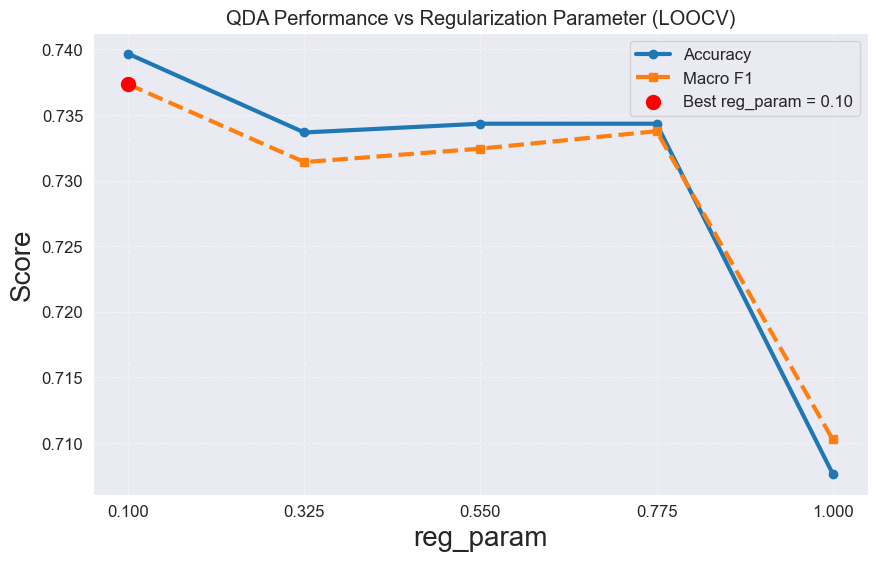

In [20]:
# Define range of QDA regularization parameters
reg_params = np.linspace(0.1, 1.0, 5)  # 0.0, 0.1, ..., 1.0

qda_results_list = []

# Evaluate QDA for each reg_param
for reg in reg_params:
    result = evaluate_with_loo(QDA(reg_param=reg), X, y, verbose=False)
    qda_results_list.append({
        "reg_param": reg,
        "accuracy": result["accuracy"],
        "macro_f1": result["macro_f1"]
    })

# Convert results to DataFrame
qda_results_df = pd.DataFrame(qda_results_list)

# Find the best reg_param based on Macro F1
best_idx = qda_results_df["macro_f1"].idxmax()
best_reg = qda_results_df.loc[best_idx, "reg_param"]
best_macro_f1 = qda_results_df.loc[best_idx, "macro_f1"]

print(f"\nBest QDA reg_param: {best_reg:.2f} with Macro F1-score: {best_macro_f1:.4f}")

# ----------------------------------------------------------
# Plot Accuracy and Macro F1 vs reg_param
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(qda_results_df["reg_param"], qda_results_df["accuracy"], marker='o', linestyle='-', label="Accuracy")
plt.plot(qda_results_df["reg_param"], qda_results_df["macro_f1"], marker='s', linestyle='--', label="Macro F1")

# Highlight best reg_param
plt.scatter(best_reg, best_macro_f1, color='red', s=100, zorder=5, label=f"Best reg_param = {best_reg:.2f}")

plt.title("QDA Performance vs Regularization Parameter (LOOCV)")
plt.xlabel("reg_param")
plt.ylabel("Score")
plt.xticks(reg_params)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [21]:
print("\nClassification report for best QDA reg_param:")
qda_best_result = evaluate_with_loo(QDA(reg_param=best_reg), X, y, verbose=True)


Classification report for best QDA reg_param:

Model: QuadraticDiscriminantAnalysis
              precision    recall  f1-score   support

    class_45       0.60      0.80      0.69      1000
    class_65       0.96      0.90      0.93      1000
    class_73       0.71      0.51      0.59      1000

    accuracy                           0.74      3000
   macro avg       0.76      0.74      0.74      3000
weighted avg       0.76      0.74      0.74      3000

Accuracy: 0.7397
Macro F1-score: 0.7373


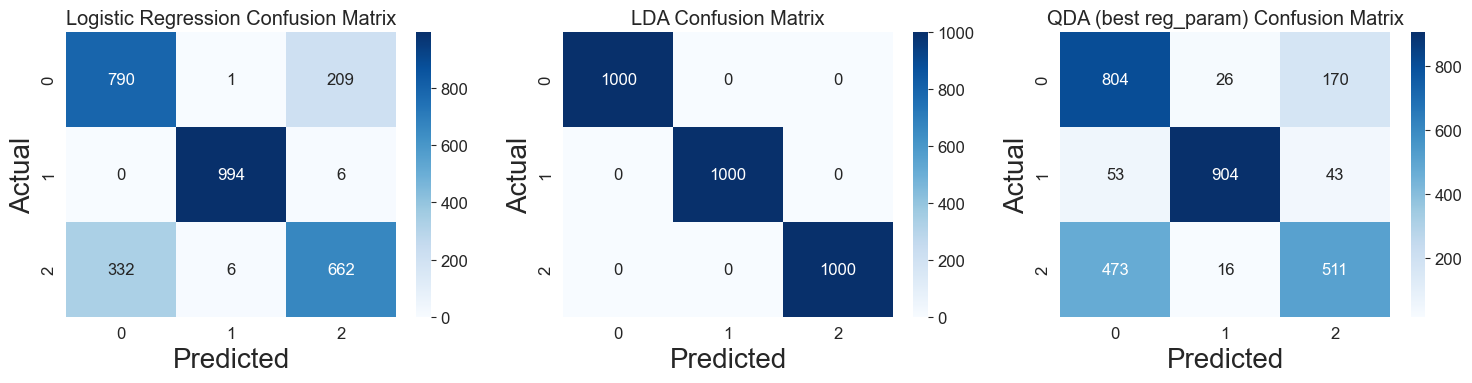

In [22]:
models_preds = {
    "Logistic Regression": logreg_result,
    "LDA": lda_result,
    "QDA (best reg_param)": qda_best_result
}

# ----------------------------------------------------------
# Plot confusion matrices
# ----------------------------------------------------------
plt.figure(figsize=(15, 4))
for i, (name, result) in enumerate(models_preds.items(), 1):
    plt.subplot(1, 3, i)
    cm = confusion_matrix(result["y_true"], result["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

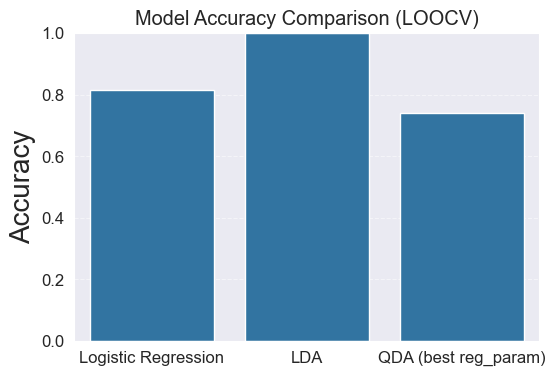

In [23]:
accuracies = {
    "Logistic Regression": logreg_result["accuracy"],
    "LDA": lda_result["accuracy"],
    "QDA (best reg_param)": qda_best_result["accuracy"]
}

# Plot bar chart
plt.figure(figsize=(6, 4))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.title("Model Accuracy Comparison (LOOCV)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Model Performance Analysis

**LDA**

* Assumes each class is Gaussian with the **same covariance**.
* `class_65` is well-separated; `class_45` and `class_73` slightly overlap.
* LDA can find a linear combination that perfectly separates classes.
* **Accuracy:** 1.0

**Logistic Regression (OvR)**

* Assumes **linear decision boundaries** per class.
* Overlap between `class_45` and `class_73` causes misclassifications.
* **Accuracy:** ~0.82

**QDA**

* Assumes each class has its **own covariance** → flexible boundaries.
* Covariance estimation can be noisy with 1000 samples per class, even with regularization.
* Misclassifications occur mostly between overlapping classes.
* **Accuracy:** ~0.74
